# Assignment 4  Customer, Product & Order Analysis


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Locate the repository/assignment data folder
for candidate in (Path.cwd(), Path.cwd().parent, Path.cwd() / "Day 4" / "Assignment 4"):
    if (candidate / "data").exists():
        BASE = candidate
        break
else:
    raise FileNotFoundError("Run this notebook from the repository or assignment folder.")

DATA = BASE / "data"
OUTPUT = BASE / "output"
OUTPUT.mkdir(exist_ok=True)

print("Base path:", BASE)

Base path: d:\IIT-M\Day 4\Assignment 4


## Part A — Understanding Individual Datasets

In [2]:
# 1. Load all three CSV files
customers = pd.read_csv(DATA / "customers.csv")
products = pd.read_csv(DATA / "products.csv")
orders = pd.read_csv(DATA / "orders.csv")

datasets = {
    "Customers": customers,
    "Products": products,
    "Orders": orders
}

# 2. Display dimensions
for name, frame in datasets.items():
    print(f"{name}: {frame.shape}")

# 3. Identify columns in each dataset
for name, frame in datasets.items():
    print(f"\n{name} columns:")
    print(list(frame.columns))

# 4. Identify common columns between datasets
print("\nCommon columns:")
for name_a, frame_a in datasets.items():
    for name_b, frame_b in datasets.items():
        if name_a < name_b:
            common = sorted(set(frame_a.columns) & set(frame_b.columns))
            print(f"{name_a} + {name_b}: {common}")

# 5. Determine relationships
print("\nDataset relationships:")
print("- customers.Customer_ID -> orders.Customer_ID")
print("- products.Product_ID -> orders.Product_ID")
print("- orders is the transaction/fact table connecting customers and products.")

Customers: (3000, 5)
Products: (100, 4)
Orders: (15000, 5)

Customers columns:
['Customer_ID', 'Customer_Name', 'City', 'Age', 'Gender']

Products columns:
['Product_ID', 'Product_Name', 'Category', 'Price']

Orders columns:
['Order_ID', 'Customer_ID', 'Product_ID', 'Quantity', 'Order_Date']

Common columns:
Customers + Products: []
Customers + Orders: ['Customer_ID']
Orders + Products: ['Product_ID']

Dataset relationships:
- customers.Customer_ID -> orders.Customer_ID
- products.Product_ID -> orders.Product_ID
- orders is the transaction/fact table connecting customers and products.


## Part B — Data Cleaning

In [3]:
# 6. Missing values
for name, frame in datasets.items():
    print(f"\n{name} missing values:")
    display(frame.isna().sum().to_frame("Missing_Count"))

# 7. Duplicate records
for name, frame in datasets.items():
    print(f"{name} duplicate rows:", frame.duplicated().sum())

# Remove duplicate primary-key records before merging.
customers = customers.drop_duplicates(subset="Customer_ID").copy()
products = products.drop_duplicates(subset="Product_ID").copy()
orders = orders.drop_duplicates(subset="Order_ID").copy()

# 8. Check validity of Customer_ID and Product_ID
print("\nMissing Customer_ID in orders:", orders["Customer_ID"].isna().sum())
print("Missing Product_ID in orders:", orders["Product_ID"].isna().sum())

valid_customer_mask = orders["Customer_ID"].isin(customers["Customer_ID"])
valid_product_mask = orders["Product_ID"].isin(products["Product_ID"])

invalid_customer_orders = orders.loc[~valid_customer_mask]
invalid_product_orders = orders.loc[~valid_product_mask]

print("Invalid customer references:", len(invalid_customer_orders))
print("Invalid product references:", len(invalid_product_orders))

# 9. Convert Order_Date into datetime
orders["Order_Date"] = pd.to_datetime(orders["Order_Date"], errors="coerce")
print("Invalid Order_Date values:", orders["Order_Date"].isna().sum())

# 10. Check whether every order corresponds to a valid customer
valid_customer_percentage = valid_customer_mask.mean() * 100
print(f"Valid customer references: {valid_customer_percentage:.2f}%")

# 11. Check whether every order corresponds to a valid product
valid_product_percentage = valid_product_mask.mean() * 100
print(f"Valid product references: {valid_product_percentage:.2f}%")


Customers missing values:


,Missing_Count
Customer_ID,0
Customer_Name,0
City,0
Age,0
Gender,0



Products missing values:


,Missing_Count
Product_ID,0
Product_Name,0
Category,0
Price,0



Orders missing values:


,Missing_Count
Order_ID,0
Customer_ID,0
Product_ID,0
Quantity,0
Order_Date,0


Customers duplicate rows: 0
Products duplicate rows: 0
Orders duplicate rows: 0

Missing Customer_ID in orders: 0
Missing Product_ID in orders: 0
Invalid customer references: 0
Invalid product references: 0
Invalid Order_Date values: 0
Valid customer references: 100.00%
Valid product references: 100.00%


## Part C — Combining DataFrames

In [4]:
# 12. Merge orders with customers
orders_with_customers = orders.merge(
    customers,
    on="Customer_ID",
    how="inner",
    validate="many_to_one"
)

# 13. Merge resulting DataFrame with products
df = orders_with_customers.merge(
    products,
    on="Product_ID",
    how="inner",
    validate="many_to_one"
)

# 14. Final consolidated DataFrame
print("Consolidated DataFrame shape:", df.shape)
print("Consolidated columns:")
print(list(df.columns))
display(df.head())

Consolidated DataFrame shape: (15000, 12)
Consolidated columns:
['Order_ID', 'Customer_ID', 'Product_ID', 'Quantity', 'Order_Date', 'Customer_Name', 'City', 'Age', 'Gender', 'Product_Name', 'Category', 'Price']


,Order_ID,Customer_ID,Product_ID,Quantity,Order_Date,Customer_Name,City,Age,Gender,Product_Name,Category,Price
0,O000001,C00861,P0027,4,2025-01-01 00:00:00,Customer_861,Kolkata,51,Female,Product_27,Sports,56171.59
1,O000002,C01295,P0047,3,2025-01-01 02:00:00,Customer_1295,Bangalore,43,Male,Product_47,Clothing,80831.23
2,O000003,C01131,P0099,4,2025-01-01 04:00:00,Customer_1131,Pune,47,Female,Product_99,Electronics,83546.72
3,O000004,C01096,P0006,1,2025-01-01 06:00:00,Customer_1096,Delhi,29,Male,Product_6,Clothing,651.66
4,O000005,C01639,P0060,2,2025-01-01 08:00:00,Customer_1639,Coimbatore,67,Female,Product_60,Sports,81819.68


## Part D — Business Calculations

In [5]:
# 15. Order Value
df["Order_Value"] = df["Price"] * df["Quantity"]

# 16. Total revenue
total_revenue = df["Order_Value"].sum()

# 17. Average order value
average_order_value = df["Order_Value"].mean()

# 18. Revenue by product category
revenue_by_category = (
    df.groupby("Category")["Order_Value"]
      .sum()
      .sort_values(ascending=False)
)

# 19. Revenue by city
revenue_by_city = (
    df.groupby("City")["Order_Value"]
      .sum()
      .sort_values(ascending=False)
)

# 20. Top 10 customers by spending
customer_spend = (
    df.groupby(["Customer_ID", "Customer_Name"], as_index=False)["Order_Value"]
      .sum()
      .sort_values("Order_Value", ascending=False)
)
top_10_customers = customer_spend.head(10)

# 21. Top 10 products by revenue
top_10_products = (
    df.groupby("Product_Name")["Order_Value"]
      .sum()
      .nlargest(10)
)

# 22. Most frequently purchased product (by quantity)
product_quantity = df.groupby("Product_Name")["Quantity"].sum().sort_values(ascending=False)
most_purchased_product = product_quantity.idxmax()

# 23. City with the highest number of customers
customers_by_city = (
    customers.groupby("City")["Customer_ID"]
             .nunique()
             .sort_values(ascending=False)
)
top_customer_city = customers_by_city.idxmax()

# 24. City generating highest revenue
top_revenue_city = revenue_by_city.idxmax()

print(f"Total revenue: {total_revenue:,.2f}")
print(f"Average order value: {average_order_value:,.2f}")

print("\nRevenue by category:")
display(revenue_by_category.to_frame("Revenue"))

print("Revenue by city:")
display(revenue_by_city.to_frame("Revenue"))

print("Top 10 customers:")
display(top_10_customers)

print("Top 10 products by revenue:")
display(top_10_products.to_frame("Revenue"))

print(f"Most frequently purchased product: {most_purchased_product}")
print(f"City with highest number of customers: {top_customer_city}")
print(f"City generating highest revenue: {top_revenue_city}")

Total revenue: 2,233,171,871.30
Average order value: 148,878.12

Revenue by category:


,Revenue
Category,
Sports,5.426713e+08
Clothing,4.261489e+08
Home Appliances,3.313110e+08
Electronics,3.312926e+08
Books,3.050563e+08
Beauty,2.966918e+08


Revenue by city:


,Revenue
City,
Kolkata,3.155500e+08
Hyderabad,2.932639e+08
Coimbatore,2.831225e+08
Mumbai,2.803566e+08
Pune,2.797505e+08
Delhi,2.654541e+08
Bangalore,2.637059e+08
Chennai,2.519685e+08


Top 10 customers:


,Customer_ID,Customer_Name,Order_Value
16,C00019,Customer_19,3176078.87
2872,C02897,Customer_2897,2528868.53
1896,C01915,Customer_1915,2476932.74
2688,C02709,Customer_2709,2400905.35
183,C00187,Customer_187,2394078.09
678,C00685,Customer_685,2352464.63
1283,C01297,Customer_1297,2345815.39
254,C00259,Customer_259,2330070.43
912,C00921,Customer_921,2257528.60
266,C00271,Customer_271,2226186.64


Top 10 products by revenue:


,Revenue
Product_Name,
Product_74,47258003.68
Product_88,47213343.92
Product_3,47075130.00
Product_46,45000771.20
Product_52,44990386.56
Product_73,44897635.86
Product_68,44696626.32
Product_38,43658393.09
Product_54,40946977.89


Most frequently purchased product: Product_15
City with highest number of customers: Kolkata
City generating highest revenue: Kolkata


## Part E — Customer Analysis

In [6]:
# 25. Divide customers into age groups
customers["Age_Group"] = pd.cut(
    customers["Age"],
    bins=[17, 30, 45, 60, float("inf")],
    labels=["18–30", "31–45", "46–60", "61+"],
    right=True
)

# Add age group to consolidated order data
df = df.drop(columns=["Age_Group"], errors="ignore")
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[17, 30, 45, 60, float("inf")],
    labels=["18–30", "31–45", "46–60", "61+"],
    right=True
)

# 26. Revenue generated by each age group
revenue_by_age_group = (
    df.groupby("Age_Group", observed=True)["Order_Value"]
      .sum()
)

# 27. Compare spending between male and female customers
revenue_by_gender = df.groupby("Gender")["Order_Value"].sum().sort_values(ascending=False)
average_spending_by_gender = df.groupby("Gender")["Order_Value"].mean().sort_values(ascending=False)

# 28. Identify high-value customers
# Define high-value customers as those at or above the 90th percentile of total spending.
high_value_threshold = customer_spend["Order_Value"].quantile(0.90)
high_value_customers = customer_spend[customer_spend["Order_Value"] >= high_value_threshold].copy()

# 29. Percentage of customers who placed more than one order
orders_per_customer = orders.groupby("Customer_ID")["Order_ID"].nunique()
customer_ids = customers["Customer_ID"]
placed_more_than_one = orders_per_customer.reindex(customer_ids, fill_value=0).gt(1)
percentage_multiple_orders = placed_more_than_one.mean() * 100

print("Revenue by age group:")
display(revenue_by_age_group.to_frame("Revenue"))

print("Total spending by gender:")
display(revenue_by_gender.to_frame("Total Spending"))

print("Average spending per order by gender:")
display(average_spending_by_gender.to_frame("Average Order Spending"))

print(f"High-value customer threshold: {high_value_threshold:,.2f}")
print("High-value customers:")
display(high_value_customers)

print(f"Percentage of customers with more than one order: {percentage_multiple_orders:.2f}%")

Revenue by age group:


,Revenue
Age_Group,
18–30,5.586278e+08
31–45,6.223524e+08
46–60,6.599237e+08
61+,3.922680e+08


Total spending by gender:


,Total Spending
Gender,
Male,1.154200e+09
Female,1.078972e+09


Average spending per order by gender:


,Average Order Spending
Gender,
Male,150639.544127
Female,147038.932161


High-value customer threshold: 1,339,423.81
High-value customers:


,Customer_ID,Customer_Name,Order_Value
16,C00019,Customer_19,3176078.87
2872,C02897,Customer_2897,2528868.53
1896,C01915,Customer_1915,2476932.74
2688,C02709,Customer_2709,2400905.35
183,C00187,Customer_187,2394078.09
...,...,...,...
460,C00465,Customer_465,1344033.24
358,C00363,Customer_363,1343700.29
2178,C02198,Customer_2198,1343095.17
1773,C01791,Customer_1791,1340820.69


Percentage of customers with more than one order: 96.03%


## Part F — Advanced Analysis

In [7]:
# 30. Customer spending ranking
customer_spend["Spending_Rank"] = (
    customer_spend["Order_Value"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

customer_spending_ranking = customer_spend.sort_values("Spending_Rank")

# 31. Top 10% of customers based on total spending
top_10_count = max(1, int(len(customer_spending_ranking) * 0.10))
top_10_percent_customers = customer_spending_ranking.head(top_10_count)

# 32. Most profitable/revenue-generating product category for each city
city_category_revenue = (
    df.groupby(["City", "Category"])["Order_Value"]
      .sum()
)
most_profitable_category_by_city = city_category_revenue.groupby(level="City").idxmax()

# 33. Most popular product in each category (by quantity purchased)
category_product_quantity = (
    df.groupby(["Category", "Product_Name"])["Quantity"]
      .sum()
)
most_popular_product_by_category = category_product_quantity.groupby(level="Category").idxmax()

# 34. Monthly revenue
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)
monthly_revenue = df.groupby("Month")["Order_Value"].sum()

# 35. Highest revenue month
highest_revenue_month = monthly_revenue.idxmax()

print("Customer spending ranking:")
display(customer_spending_ranking)

print("Top 10% customers:")
display(top_10_percent_customers)

print("Most profitable category for each city:")
display(most_profitable_category_by_city.to_frame("City + Category"))

print("Most popular product in each category:")
display(most_popular_product_by_category.to_frame("Category + Product"))

print("Monthly revenue:")
display(monthly_revenue.to_frame("Revenue"))

print(f"Highest revenue month: {highest_revenue_month}")

Customer spending ranking:


,Customer_ID,Customer_Name,Order_Value,Spending_Rank
16,C00019,Customer_19,3176078.87,1
2872,C02897,Customer_2897,2528868.53,2
1896,C01915,Customer_1915,2476932.74,3
2688,C02709,Customer_2709,2400905.35,4
183,C00187,Customer_187,2394078.09,5
...,...,...,...,...
1159,C01172,Customer_1172,7497.06,2960
870,C00879,Customer_879,4561.62,2961
570,C00577,Customer_577,2606.64,2962
2016,C02035,Customer_2035,2383.56,2963


Top 10% customers:


,Customer_ID,Customer_Name,Order_Value,Spending_Rank
16,C00019,Customer_19,3176078.87,1
2872,C02897,Customer_2897,2528868.53,2
1896,C01915,Customer_1915,2476932.74,3
2688,C02709,Customer_2709,2400905.35,4
183,C00187,Customer_187,2394078.09,5
...,...,...,...,...
1031,C01044,Customer_1044,1344617.29,293
460,C00465,Customer_465,1344033.24,294
358,C00363,Customer_363,1343700.29,295
2178,C02198,Customer_2198,1343095.17,296


Most profitable category for each city:


...

Most popular product in each category:


,Category + Product
Category,
Beauty,"(Beauty, Product_10)"
Books,"(Books, Product_63)"
Clothing,"(Clothing, Product_15)"
Electronics,"(Electronics, Product_54)"
Home Appliances,"(Home Appliances, Product_17)"
Sports,"(Sports, Product_96)"


Monthly revenue:


,Revenue
Month,
2025-01,53361220.93
2025-02,52963079.79
2025-03,56233288.12
2025-04,50923849.46
2025-05,57301343.61
2025-06,56460489.60
2025-07,54157148.69
2025-08,57144165.05
2025-09,53352193.95


Highest revenue month: 2025-12


## Visualizations

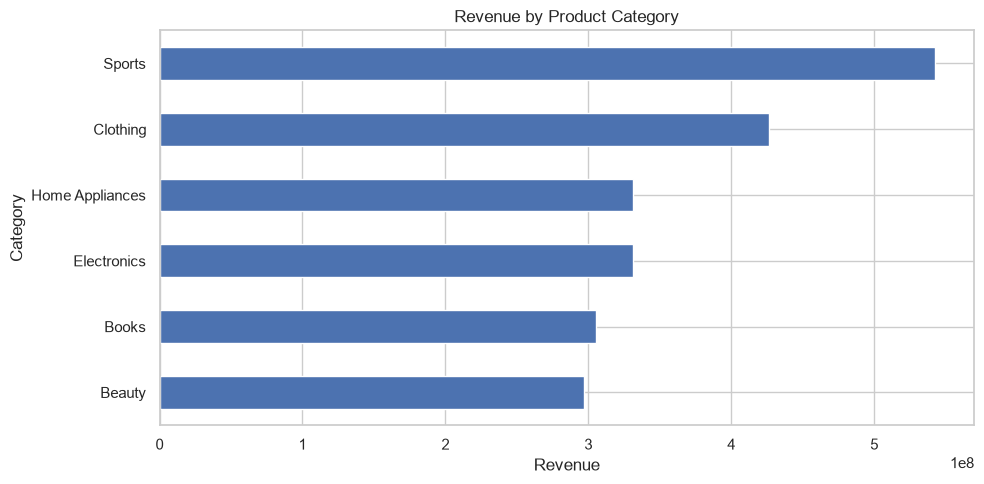

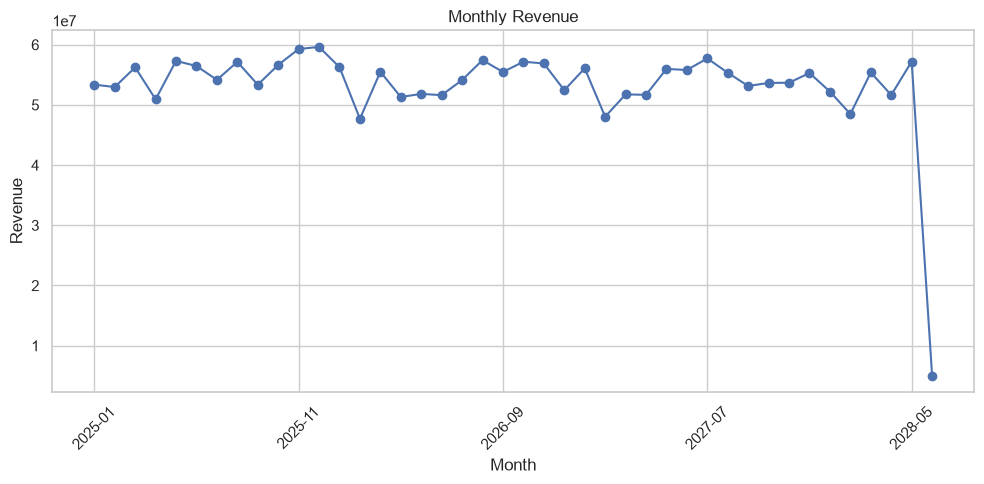

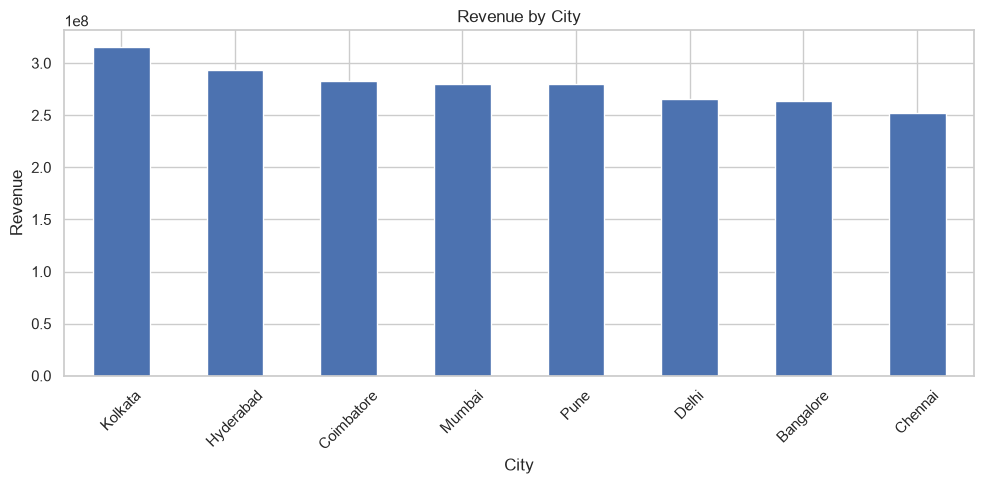

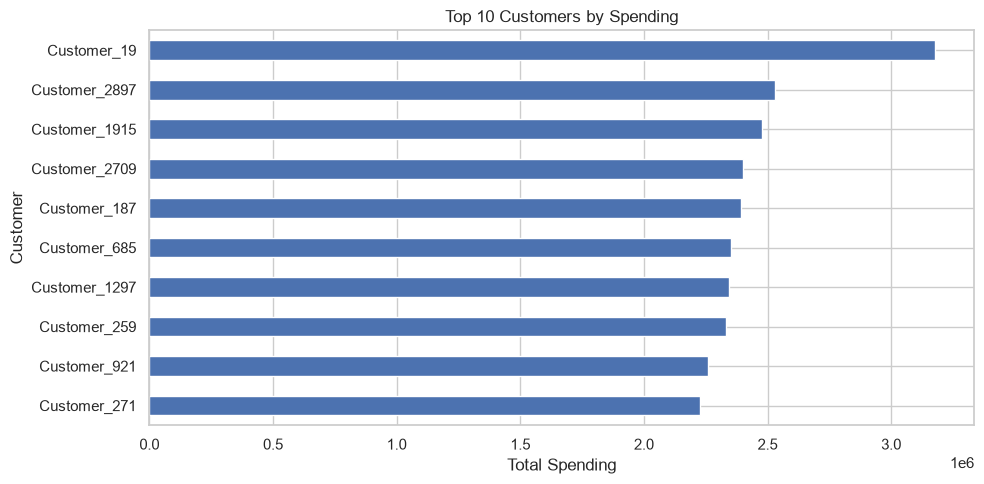

In [8]:
sns.set_theme(style="whitegrid")

# Revenue by category
plt.figure(figsize=(10, 5))
revenue_by_category.sort_values().plot(kind="barh")
plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(OUTPUT / "revenue_by_category.png", dpi=150)
plt.show()
plt.close()

# Monthly revenue
plt.figure(figsize=(10, 5))
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT / "monthly_revenue.png", dpi=150)
plt.show()
plt.close()

# Revenue by city
plt.figure(figsize=(10, 5))
revenue_by_city.plot(kind="bar")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT / "revenue_by_city.png", dpi=150)
plt.show()
plt.close()

# Customer spending ranking
plt.figure(figsize=(10, 5))
customer_spending_ranking.head(10).set_index("Customer_Name")["Order_Value"].sort_values().plot(kind="barh")
plt.title("Top 10 Customers by Spending")
plt.xlabel("Total Spending")
plt.ylabel("Customer")
plt.tight_layout()
plt.savefig(OUTPUT / "top_10_customers.png", dpi=150)
plt.show()
plt.close()

## Save Outputs

In [9]:
df.to_csv(OUTPUT / "consolidated_orders.csv", index=False)
customer_spending_ranking.to_csv(OUTPUT / "customer_spending_ranking.csv", index=False)
top_10_percent_customers.to_csv(OUTPUT / "top_10_percent_customers.csv", index=False)

print("Saved:")
print(OUTPUT / "consolidated_orders.csv")
print(OUTPUT / "customer_spending_ranking.csv")
print(OUTPUT / "top_10_percent_customers.csv")

Saved:
d:\IIT-M\Day 4\Assignment 4\output\consolidated_orders.csv
d:\IIT-M\Day 4\Assignment 4\output\customer_spending_ranking.csv
d:\IIT-M\Day 4\Assignment 4\output\top_10_percent_customers.csv
